# Sparsity Study.

This script studies the Sparsity of optimal solutions within certain SimOpt problems. It is our belief that problems with basi

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [273]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [274]:
# Specify the names of the solver and problem to test.
# Example with random search solver on continuous newsvendor problem:
# solver_abbr_name = "RNDSRCH"
# problem_abbr_name = "CNTNEWS-1"
solver_abbr_name = "RNDSRCH"
problem_abbr_name = "ROSENBROCK-1"

num_macroreps = 5
num_postreps = 2
num_postreps_init_opt = 2

In [275]:
# If the solver runs have already been performed, specify the file name path.
# If no path is specified, a new run will be performed.
file_name_path = None

if file_name_path is None:
    # Import the ProblemSolver class and other useful functions
    from simopt.experiment_base import ProblemSolver

    # Initialize an instance of the experiment class.
    myexperiment = ProblemSolver(solver_abbr_name, problem_abbr_name, problem_fixed_factors={'budget': 10000})#, solver_fixed_factors={'initial subspace dimension': 2, 'polynomial degree': 2})

    # Run a fixed number of macroreplications of the solver on the problem.
    myexperiment.run(n_macroreps=num_macroreps)
else:
    # following pair of lines (and uncomment the myexperiment.run(...)§
    # line above) to read in results from a .pickle file.
    # file_name_path = ""
    from simopt.experiment_base import read_experiment_results

    myexperiment = read_experiment_results(file_name_path)

Random Search sampled new solution: (np.float64(-0.21677401012418288), np.float64(-0.5538476178659764), np.float64(-0.7574232339588745), np.float64(-0.002922924918520259), np.float64(-0.5350767254581593), np.float64(1.5870013422554732), np.float64(0.8085924283525604), np.float64(-1.1065686845852425), np.float64(0.6712334456638059), np.float64(0.10447299076992096), np.float64(-0.9351540738719397), np.float64(-0.6365352075610712), np.float64(-0.0418535160883509), np.float64(2.0076134618154815), np.float64(1.1372060433554043))
Random Search sampled new solution: (np.float64(1.6944691211337697), np.float64(-0.6828619878763936), np.float64(-0.5171641665181963), np.float64(0.12687336202193591), np.float64(0.052303295948190935), np.float64(0.3264410654118311), np.float64(0.9981378663900109), np.float64(-0.37111538608543365), np.float64(-0.11446324186296256), np.float64(0.6521561976572106), np.float64(-0.4476556958665241), np.float64(1.4795287213850048), np.float64(-0.08994701460160721), np.fl

In [276]:
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=num_postreps)

In [277]:
# Find an optimal solution x* for normalization.
from simopt.experiment_base import post_normalize

post_normalize([myexperiment], n_postreps_init_opt=num_postreps_init_opt)

In [278]:
# Log results.
myexperiment.log_experiment_results()

Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-28_23-17-24/plots/SOLVER_SET_ROSENBROCK-1_all_prog_curves_unnorm (1) (2) (3) (4).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-28_23-17-24/plots/SOLVER_SET_ROSENBROCK-1_mean_prog_curve_unnorm (1) (2) (3) (4).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-11-28_23-17-24/plots/SOLVER_SET_ROSENBROCK-1_terminal_box_unnorm (1) (2) (3) (4).png')]
Plotting complete!


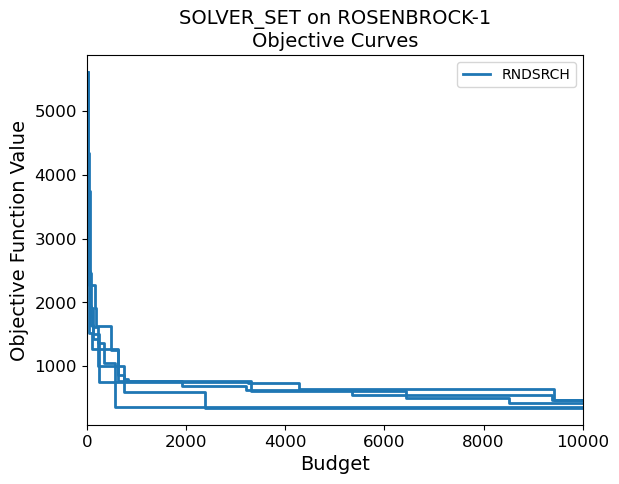

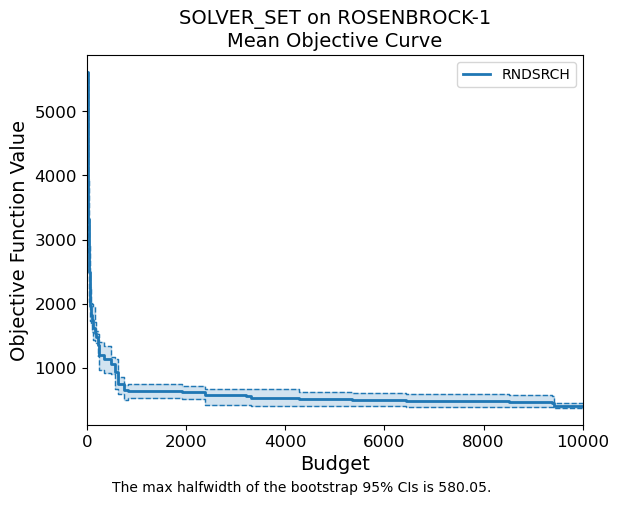

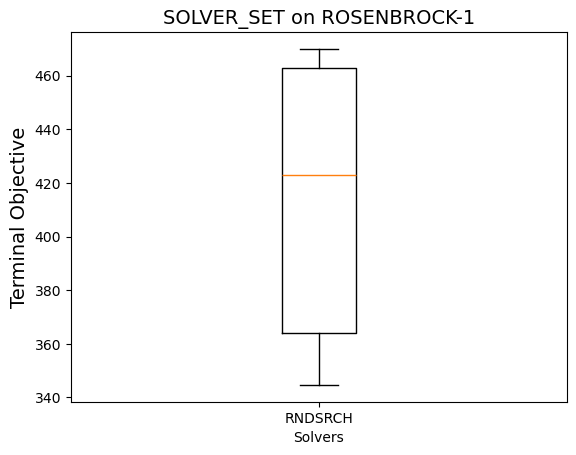

In [279]:
# Produce basic plots.
%matplotlib inline
from simopt.experiment_base import (
    PlotType,
    plot_progress_curves,
    plot_terminal_progress,
    plot_solvability_cdfs,
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
    )
)
_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.MEAN, normalize=False
    )
)

_print_path(
    plot_terminal_progress(
        experiments=[myexperiment], plot_type=PlotType.BOX, normalize=False
    )
)


print("Plotting complete!")

initial solution: [np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0), np.float64(2.0)]
final solution: [np.float64(0.7063277088432727), np.float64(0.00883180272379841), np.float64(0.6316637113504872), np.float64(0.33044877809889195), np.float64(0.5105159227120605), np.float64(0.5571938810369698), np.float64(0.6448897097933395), np.float64(0.05163681593377787), np.float64(-0.1358353295127556), np.float64(0.010473840351712749), np.float64(0.37068012811202483), np.float64(0.307619109475794), np.float64(0.5096584153229532), np.float64(0.2185970557886014), np.float64(0.5027549893864601)]
Max change in solution: 2.1358353295127555
Min change in solution: 1.2936722911567273


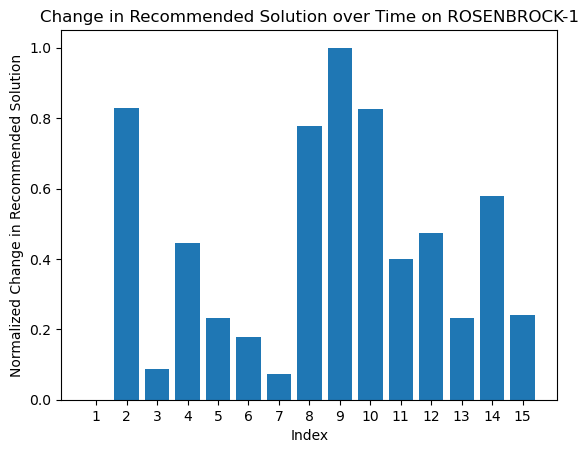

In [280]:
#Track the changes in the recommened solution over time and then take the total change and plot it as a bar chart

#First get the mean recommended xs at each iteration over all macroreps, where each recommended x in each macrorep and at a given iteraiton is a tuple,
#Want to return a list of length equal to the number of iterations, where each element is the mean recommended x at that iteration over all macroreps
import numpy as np
smallest_length = min([len(myexperiment.all_recommended_xs[macrorep]) for macrorep in range(num_macroreps)])
mean_recommended_xs = [np.mean([myexperiment.all_recommended_xs[macrorep][iter] for macrorep in range(num_macroreps)], axis=0) for iter in range(smallest_length)]

final_solution = list(mean_recommended_xs[-1])
first_solution = list(mean_recommended_xs[0])
change_in_solution = abs(np.array(final_solution) - np.array(first_solution)).tolist()

max_value = max(change_in_solution)
min_value = min(change_in_solution)

print(f'initial solution: {first_solution}')
print(f'final solution: {final_solution}')
print("Max change in solution:", max_value)
print("Min change in solution:", min_value)

change_in_solution_normalized = [(x - min_value) / (max_value - min_value) for x in change_in_solution]
#plot the final_solution as bar chart with the index on x axis and value on y axis
import matplotlib.pyplot as plt
plt.bar(range(1, len(final_solution) + 1), change_in_solution_normalized)
plt.xlabel('Index')
plt.xticks(range(1, len(final_solution) + 1))
plt.ylabel('Normalized Change in Recommended Solution')
plt.title(f'Change in Recommended Solution over Time on {problem_abbr_name}')
plt.show()

In [281]:
#Write out the LP problem of DYNAMNEWS-1